In [ ]:
import numpy as np
import cv2
import skimage.feature as sk
from skimage.transform import warp, AffineTransform
from random import sample
import matplotlib.pyplot as plt

In [ ]:
# Load the 2 images
im1 = cv2.imread('left_im.png')
im2 = cv2.imread('center_im.png')

images = [im1, im2]

In [ ]:
im1.shape

AttributeError: 'numpy.ndarray' object has no attribute 'save'

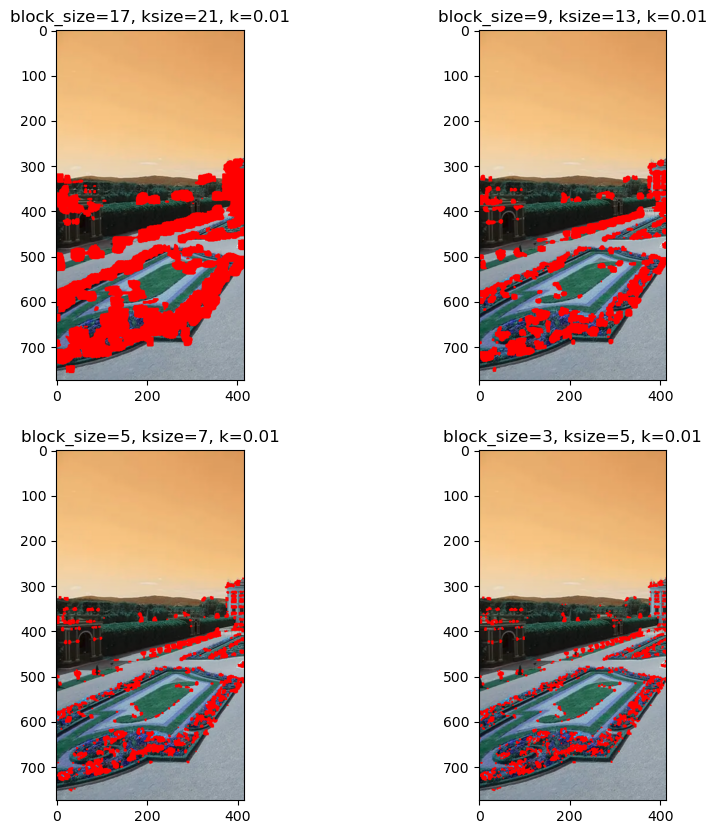

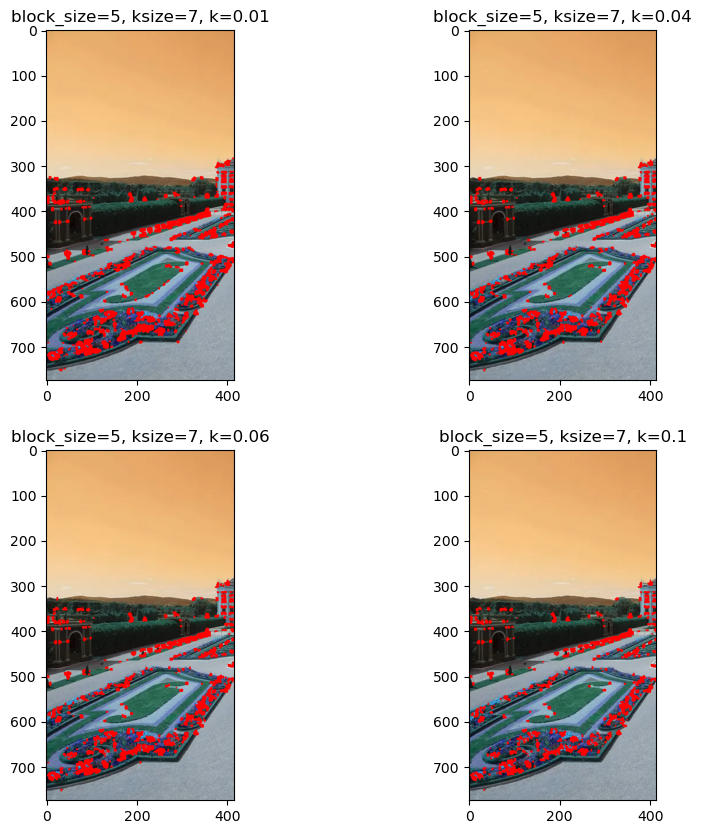

In [ ]:
# harrys corner detection
def corner_harris(image, block_size, ksize, k):
    # Convert image to gray scale
    gray_im = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray_im = np.float32(gray_im)

    # Compute the corner response function for each pixel in the image
    features_im = cv2.cornerHarris(gray_im, block_size, ksize, k)

    # Dilate the corner response function to enhance the corner points
    features_im = cv2.dilate(features_im, None)

    # Need create a new instance of the image, otherwise we cant run the test with different parameters
    # Has it will modify the original image and the next test will be run on the modified image
    image_copy = image.copy()

    # Mark the corners in the original image with a red pixel
    image_copy[features_im > 0.01 * features_im.max()] = [255, 0, 0]

    return image_copy, features_im

# Investigating the effect of the parameters on the size and number of detected corners
"""
test1_1_left, _ = corner_harris(im1, 17, 21, 0.01)
test1_2_left, _ = corner_harris(im1, 9, 13, 0.01)
test1_3_left, _ = corner_harris(im1, 5, 7, 0.01)
test1_4_left, _ = corner_harris(im1, 3, 5, 0.01)

plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.imshow(test1_1_left)
plt.title('block_size=17, ksize=21, k=0.01')
plt.subplot(2, 2, 2)
plt.imshow(test1_2_left)
plt.title('block_size=9, ksize=13, k=0.01')
plt.subplot(2, 2, 3)
plt.imshow(test1_3_left)    
plt.title('block_size=5, ksize=7, k=0.01')
plt.subplot(2, 2, 4)
plt.imshow(test1_4_left)
plt.title('block_size=3, ksize=5, k=0.01')
plt.savefig('corner_harris_block_size_ksize.png')
plt.show()

test2_1_left, _ = corner_harris(im1, 5, 7, 0.01)
test2_2_left, _ = corner_harris(im1, 5, 7, 0.04)
test2_3_left, _ = corner_harris(im1, 5, 7, 0.06)
test2_4_left, _ = corner_harris(im1, 5, 7, 0.1)

plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.imshow(test2_1_left)
plt.title('block_size=5, ksize=7, k=0.01')
plt.subplot(2, 2, 2)
plt.imshow(test2_2_left)
plt.title('block_size=5, ksize=7, k=0.04')
plt.subplot(2, 2, 3)
plt.imshow(test2_3_left)    
plt.title('block_size=5, ksize=7, k=0.06')
plt.subplot(2, 2, 4)
plt.imshow(test2_4_left)
plt.title('block_size=5, ksize=7, k=0.1')
plt.savefig('corner_harris_k.png')
plt.show()
"""

In [ ]:
harris_output = [corner_harris(img, 3, 5, 0.04) for img in images] 
harris_RGB_image = [cv2.cvtColor(x[0], cv2.COLOR_BGR2RGB) for x in harris_output]


In [ ]:
def compute_keyPoints(harris_features): 
    keypoints = []
    for i in range(harris_features.shape[0]):
        for j in range(harris_features.shape[1]):
            if harris_features[i, j] > 0.01*harris_features.max():
                keypoints.append(cv2.KeyPoint(j, i, size=16, response=float(harris_features[i, j])))
                
    return keypoints

In [ ]:
# Compute SIFT features
# First exctract the key points in each image
key_points = [compute_keyPoints(x[1]) for x in harris_output]

# We have way to many points from our Harris corner detection,
print(len(key_points[0]))

best_kps = []
for keypoints in key_points: 
    best_kp = sorted(keypoints, key=lambda kp: kp.response, reverse=True)
    best_kps.append(best_kp[:1500])

print(len(best_kps[0]))


19142
1500


In [ ]:
# Then compute the SIFT features for each image using the key points
sift = cv2.xfeatures2d.SIFT_create()
SIFT_features = [sift.compute(img, kp) for img, kp in zip(images, best_kps)]
print(SIFT_features[0])


((< cv2.KeyPoint 0x7308d71885d0>, < cv2.KeyPoint 0x7308d7188fc0>, < cv2.KeyPoint 0x7308d6db91b0>, < cv2.KeyPoint 0x7308d6db9720>, < cv2.KeyPoint 0x7308d6db9300>, < cv2.KeyPoint 0x7308d6db94e0>, < cv2.KeyPoint 0x7308d6db9900>, < cv2.KeyPoint 0x7308d6db9630>, < cv2.KeyPoint 0x7308d6db9360>, < cv2.KeyPoint 0x7308d73fce40>, < cv2.KeyPoint 0x7308d73fccf0>, < cv2.KeyPoint 0x7308d73fc5d0>, < cv2.KeyPoint 0x7308d73fced0>, < cv2.KeyPoint 0x7308d73fc420>, < cv2.KeyPoint 0x7308d73fc750>, < cv2.KeyPoint 0x7308d73fcea0>, < cv2.KeyPoint 0x7308d70950f0>, < cv2.KeyPoint 0x7309003048a0>, < cv2.KeyPoint 0x730900304ea0>, < cv2.KeyPoint 0x730900304330>, < cv2.KeyPoint 0x7309003041e0>, < cv2.KeyPoint 0x7309003041b0>, < cv2.KeyPoint 0x730900304180>, < cv2.KeyPoint 0x730900304150>, < cv2.KeyPoint 0x730900304120>, < cv2.KeyPoint 0x730900304030>, < cv2.KeyPoint 0x730900304d20>, < cv2.KeyPoint 0x730900304cf0>, < cv2.KeyPoint 0x7309003045a0>, < cv2.KeyPoint 0x730900304c30>, < cv2.KeyPoint 0x730900304510>, < cv2.

In [ ]:
# Compute the distances between every descriptor in image 1 with every descriptor in image 2. For this, use: 
# a) Normalized correlation 
# b) Euclidean distance after normalizing each descriptor.

def normalize_descriptors(descriptors):
    norms = np.linalg.norm(descriptors, axis=1, keepdims=True)
    return descriptors / norms


def euclidean_distance(desc1, desc2):
    return np.linalg.norm(desc1[:, None, :] - desc2[None, :, :], axis=2)


def normalized_correlation(desc1, desc2):
    desc1 = desc1 - desc1.mean(axis=1, keepdims=True)
    desc2 = desc2 - desc2.mean(axis=1, keepdims=True)
    return np.dot(desc1, desc2.T)

normalized_SIFT_features = [normalize_descriptors(x[1]) for x in SIFT_features]

euclidean_distances = euclidean_distance(normalized_SIFT_features[0], normalized_SIFT_features[1])
correlation = normalized_correlation(normalized_SIFT_features[0], normalized_SIFT_features[1])

print("Euclidean Distances:\n", euclidean_distances)
print("\nNormalized Correlations:\n", correlation)

Euclidean Distances:
 [[0.7716967  0.7695666  0.7700451  ... 0.619614   0.62112164 0.83263993]
 [0.77526104 0.77307606 0.7735235  ... 0.6150036  0.61654663 0.837545  ]
 [0.7788462  0.77662796 0.77705693 ... 0.61211365 0.61370325 0.8409397 ]
 ...
 [0.7425214  0.7430533  0.744643   ... 0.6407308  0.6388498  0.7830819 ]
 [0.74140894 0.7419671  0.74354076 ... 0.64014214 0.6382908  0.7798028 ]
 [0.741479   0.7421338  0.7437395  ... 0.6380363  0.6361659  0.77662915]]

Normalized Correlations:
 [[0.11569582 0.11631341 0.11600062 ... 0.23556937 0.23435345 0.08709578]
 [0.11372317 0.11439218 0.11410157 ... 0.23918088 0.23795056 0.08375683]
 [0.1111233  0.11182626 0.11154844 ... 0.24113546 0.23988123 0.08108739]
 ...
 [0.10709386 0.10562128 0.1044972  ... 0.1923078  0.19321604 0.09750247]
 [0.10606539 0.10457069 0.10346042 ... 0.19087538 0.19176272 0.09827509]
 [0.10431229 0.10274284 0.10160875 ... 0.1905608  0.19145562 0.09910253]]


In [ ]:
# Apply to all the images
distances = []
correlations = []
for i in range(len(normalized_SIFT_features)):
    for j in range(i + 1, len(normalized_SIFT_features)):
        euclidean_distances = euclidean_distance(normalized_SIFT_features[i], normalized_SIFT_features[j])
        correlation = normalized_correlation(normalized_SIFT_features[i], normalized_SIFT_features[j])
        distances.append(euclidean_distances)
        correlations.append(correlation)

In [ ]:
#Now that we have the distances and correlations, we can find the best matches between the descriptors 
def find_matches(correlations, threshold):
    matches = []
    for i in range(correlations.shape[0]):
        for j in range(correlations.shape[1]):
            if correlations[i, j] > threshold:
                matches.append((i, j))

    return matches

# Lets find the best value for the threshold: 
"""
all_thresholds = []
number_of_matches = []
for corr in correlations:
    number_of_matches.append([])
    for threshold in [0.3, 0.35,0.4, 0.45, 0.5, 0.55, 0.575, 0.6]:
        matches = find_matches(corr, threshold)
        number_of_matches[-1].append(len(matches))
        print(f"Threshold: {threshold}, Number of Matches: {len(matches)}")

plt.plot([0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.575, 0.6], number_of_matches[0])
plt.plot([0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.575, 0.6], number_of_matches[1])
plt.plot([0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.575, 0.6], number_of_matches[2])
plt.legend(['Image 1 vs Image 2', 'Image 1 vs Image 3', 'Image 2 vs Image 3'])
plt.xlabel('Threshold')
plt.ylabel('Number of Matches')
plt.title('Matching Performance vs Threshold')
plt.savefig('matching_performance_vs_threshold.png')
plt.show()
"""


'\nall_thresholds = []\nnumber_of_matches = []\nfor corr in correlations:\n    number_of_matches.append([])\n    for threshold in [0.3, 0.35,0.4, 0.45, 0.5, 0.55, 0.575, 0.6]:\n        matches = find_matches(corr, threshold)\n        number_of_matches[-1].append(len(matches))\n        print(f"Threshold: {threshold}, Number of Matches: {len(matches)}")\n\nplt.plot([0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.575, 0.6], number_of_matches[0])\nplt.plot([0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.575, 0.6], number_of_matches[1])\nplt.plot([0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.575, 0.6], number_of_matches[2])\nplt.legend([\'Image 1 vs Image 2\', \'Image 1 vs Image 3\', \'Image 2 vs Image 3\'])\nplt.xlabel(\'Threshold\')\nplt.ylabel(\'Number of Matches\')\nplt.title(\'Matching Performance vs Threshold\')\nplt.savefig(\'matching_performance_vs_threshold.png\')\nplt.show()\n'

In [ ]:
# We can see a big variance in the number of matches for the different image pairs, so I will use a top-k approach instead

def find_top_k_matches(measures, ascending, k):
    matches = []
    # Find the cut off point, when using correlation, the bigger the value the better, 
    if ascending:
        # for each point in image 1 find the point in image 2 with the highest correlation value  
        for i in range(measures.shape[0]):
            best_match = np.argmax(measures[i])
            matches.append((i, best_match))

    # while for distances we want the smallest ones
    else:
        for i in range(measures.shape[0]):
            best_match = np.argmin(measures[i])
            matches.append((i, best_match))

    # Return the matches based on the cutoff point on the sorted values
    sorted_matches = sorted(matches, key=lambda match: measures[match[0], match[1]], reverse=ascending)

    return sorted_matches[:k] 

# Lets investigate the effect of k on the quality of the matches
"""
corr_quality_idx = []
dist_quality_idx = []
k_values = [100, 200, 300, 400, 500, 750]
for k in k_values:
    corr_quality_idx.append(find_top_k_matches(correlations[0], ascending=True, k=k))
    dist_quality_idx.append(find_top_k_matches(distances[0], ascending=False, k=k))

corr_quality = [[correlations[0][match[0], match[1]] for match in subset] for subset in corr_quality_idx]
dist_quality = [[distances[0][match[0], match[1]] for match in subset] for subset in dist_quality_idx]

plt.plot(k_values, [np.mean(q) for q in corr_quality])  
plt.plot(k_values, [np.mean(q) for q in dist_quality])
plt.legend(['Correlation', 'Distance'])
plt.xlabel('k')
plt.ylabel('Average Quality')
plt.title('Matching Performance vs k')
plt.savefig('matching_performance_vs_k.png')
plt.show()
"""

"\ncorr_quality_idx = []\ndist_quality_idx = []\nk_values = [100, 200, 300, 400, 500, 750]\nfor k in k_values:\n    corr_quality_idx.append(find_top_k_matches(correlations[0], ascending=True, k=k))\n    dist_quality_idx.append(find_top_k_matches(distances[0], ascending=False, k=k))\n\ncorr_quality = [[correlations[0][match[0], match[1]] for match in subset] for subset in corr_quality_idx]\ndist_quality = [[distances[0][match[0], match[1]] for match in subset] for subset in dist_quality_idx]\n\nplt.plot(k_values, [np.mean(q) for q in corr_quality])  \nplt.plot(k_values, [np.mean(q) for q in dist_quality])\nplt.legend(['Correlation', 'Distance'])\nplt.xlabel('k')\nplt.ylabel('Average Quality')\nplt.title('Matching Performance vs k')\nplt.savefig('matching_performance_vs_k.png')\nplt.show()\n"

In [ ]:
filtered_corr_matches = [find_top_k_matches(corr, ascending=True,k=400) for corr in correlations]
filtered_dist_matches = [find_top_k_matches(dist, ascending=False, k=400) for dist in distances]  

In [ ]:
# Compute the affine transformation matrix that maps points1 to points2
def affine_transformation(points1, points2):
    A = []
    B = []
    # Equations set up, for each pair of points
    for (x1, y1), (x2, y2) in zip(points1, points2):
        A.append([x1, y1, 0, 0, 1, 0])
        A.append([0, 0, x1, y1, 0, 1])
        B.append(x2)
        B.append(y2)

    A = np.array(A)
    B = np.array(B)

    # Use least square to solve the equation
    params = np.linalg.lstsq(A, B, rcond=None)[0]
    return params.reshape(2, 3)

# Apply the affine transformation to a point
def apply_transform(model, point):
    x, y = point
    a, b, c, d, e, f = model.flatten()

    predicted_x = a * x + b * y + e
    predicted_y = c * x + d * y + f
    
    return np.array([predicted_x, predicted_y])


def RANSAC(matches, im_1_kp, im_2_kp):
    s = 4 # the smallest number of points needed, between 3-5
    N = 1000 # Number of iteration needed 
    d = 0.3 # threshold to identify inliers
    T = 10 # Number of accepted point to validate the model

    best_model = None
    best_inliers = []
    best_outliers = []
    residuals = []
    all_inliers = []

    for i in range(N):
        # draw a sample of s points from the data (randomly selected)
        sampled_idx = sample(matches, s)

        points1 = np.array([im_1_kp[idx1].pt for idx1, idx2 in sampled_idx])
        points2 = np.array([im_2_kp[idx2].pt for idx1, idx2 in sampled_idx])  
        
        # Fit a model to them
        model = affine_transformation(points1, points2)

        # Find outliers 
        # For each data point outside the s points
        outliers = []
        inliers = []
        for matche in matches:
            if matche not in sampled_idx:
                # Test its distance from the model (e.g. the line) and compare it with d
                kp_1 = np.array(im_1_kp[matche[0]].pt)
                kp_2 = np.array(im_2_kp[matche[1]].pt)

                # Compute the projected point using the model
                predicted = apply_transform(model, kp_1)

                if np.linalg.norm(predicted - kp_2) > d:
                    outliers.append(matche)
                    residuals.append(np.linalg.norm(predicted - kp_2))

                else:
                    inliers.append(matche)
        
        all_inliers.append(inliers)
        # If there are T or more points satisfying the above condition, this is a good model. 
        # Refit the model using all these inliers
        if len(inliers) >= T:
            best_points_1 = np.array([im_1_kp[idx1].pt for idx1, idx2 in inliers])
            best_points_2 = np.array([im_2_kp[idx2].pt for idx1, idx2 in inliers])

            new_model = affine_transformation(best_points_1, best_points_2)

            # Save the best model and its inliers
            if len(inliers) > len(best_inliers):
                best_inliers = inliers
                best_outliers = outliers
                best_model = new_model

    print(f"Avg inliers: {np.mean([len(inliers) for inliers in all_inliers])}")
    print(f"Number of inliers: {len(best_inliers)}, Number of outliers: {len(best_outliers)}")
    print(f"Average residual: {np.mean(residuals)}")

    return best_model, best_inliers

matches = filtered_dist_matches[0]
im_1_kp = best_kps[0]
im_2_kp = best_kps[1]

best_model, best_inliers = RANSAC(matches, im_1_kp, im_2_kp)

Avg inliers: 308.299
Number of inliers: 370, Number of outliers: 26
Average residual: 4.275233614735652


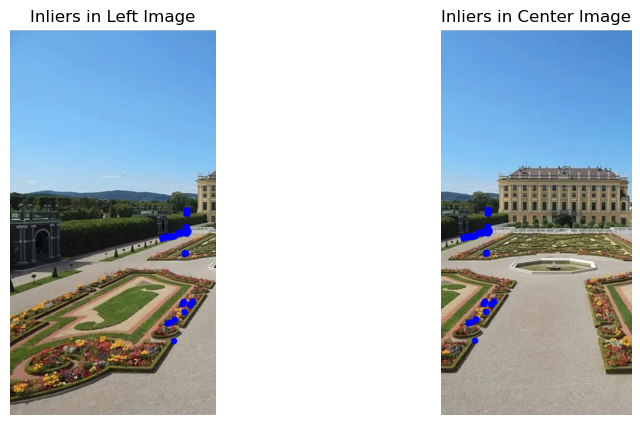

In [ ]:
# Display the location of the inliers matches on both images
im1_copy = im1.copy()
im2_copy = im2.copy()

for idx1, idx2 in best_inliers:
    kp_1 = im_1_kp[idx1].pt
    kp_2 = im_2_kp[idx2].pt

    # Add blue circles to the inlier key points in both images
    im1_copy = cv2.circle(im1_copy, (int(kp_1[0]), int(kp_1[1])), 5, (255, 0, 0), -1)
    im2_copy = cv2.circle(im2_copy, (int(kp_2[0]), int(kp_2[1])), 5, (255, 0, 0), -1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(im1_copy, cv2.COLOR_BGR2RGB))
plt.title('Inliers in Left Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(im2_copy, cv2.COLOR_BGR2RGB))
plt.title('Inliers in Center Image')
plt.axis('off')
plt.savefig('inliers.png')
plt.show()

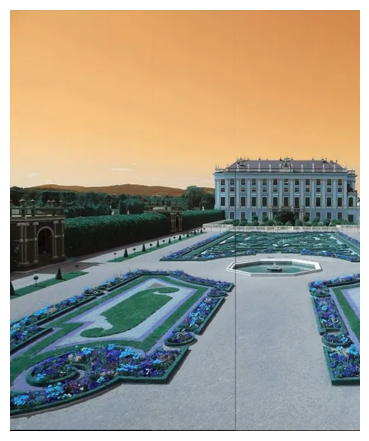

In [ ]:
# Generate transform from our inliers
tform = AffineTransform()
src = np.array([im_1_kp[idx1].pt for idx1, idx2 in best_inliers])
dst = np.array([im_2_kp[idx2].pt for idx1, idx2 in best_inliers])
tform.estimate(src, dst)

# Determine output canvas size
# Get corners of left image after transformation
h, w = im1.shape[:2]
corners = np.array([[0, 0], [w, 0], [w, h], [0, h]])
transformed_corners = tform(corners)

# Calculate bounding box for the stitched image
all_corners = np.vstack([transformed_corners, 
                         [[0, 0], [im2.shape[1], 0], 
                          [im2.shape[1], im2.shape[0]], 
                          [0, im2.shape[0]]]])
min_x, min_y = all_corners.min(axis=0)
max_x, max_y = all_corners.max(axis=0)

# Create translation to ensure all content is in positive coordinates
offset = AffineTransform(translation=(-min_x, -min_y))
combined_tform = offset + tform

# Calculate output shape
output_shape = (int(np.ceil(max_y - min_y)), int(np.ceil(max_x - min_x)))

# Warp left image
warped_left = warp(im1, inverse_map=combined_tform.inverse, 
                   output_shape=output_shape, preserve_range=True)

# Warp right image 
warped_right = warp(im2, inverse_map=offset.inverse, 
                    output_shape=output_shape, preserve_range=True)

# Blend the images 
mask_left = warped_left > 0
mask_right = warped_right > 0
overlap = mask_left & mask_right

stitched = np.zeros_like(warped_left)
stitched[mask_left & ~overlap] = warped_left[mask_left & ~overlap]
stitched[mask_right & ~overlap] = warped_right[mask_right & ~overlap]
stitched[overlap] = (warped_left[overlap] + warped_right[overlap]) / 2

# Display result
plt.imshow(stitched.astype(np.uint8))
plt.tight_layout()
plt.axis('off')
plt.savefig('stitched_image.png')
plt.show()